✅ Libraries imported!
STEP 1: Dataset Loaded
Red wine rows   : 1599
White wine rows : 4898
Total rows      : 6497
Columns         : 13
STEP 2: Pre-Processing

Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64
✅ Missing values handled
✅ wine_type encoded: red=0, white=1

Basic Statistics:


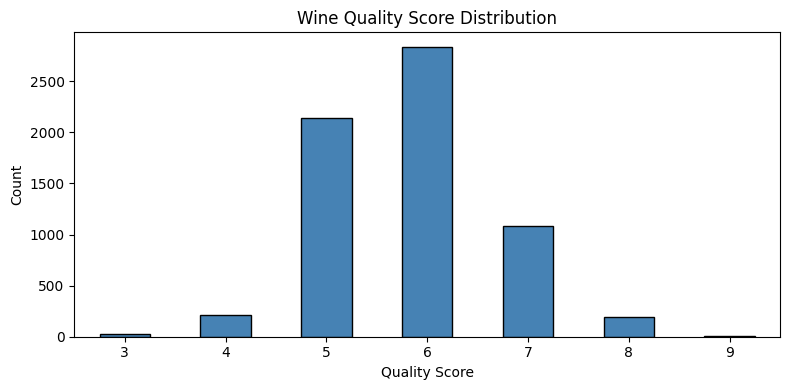

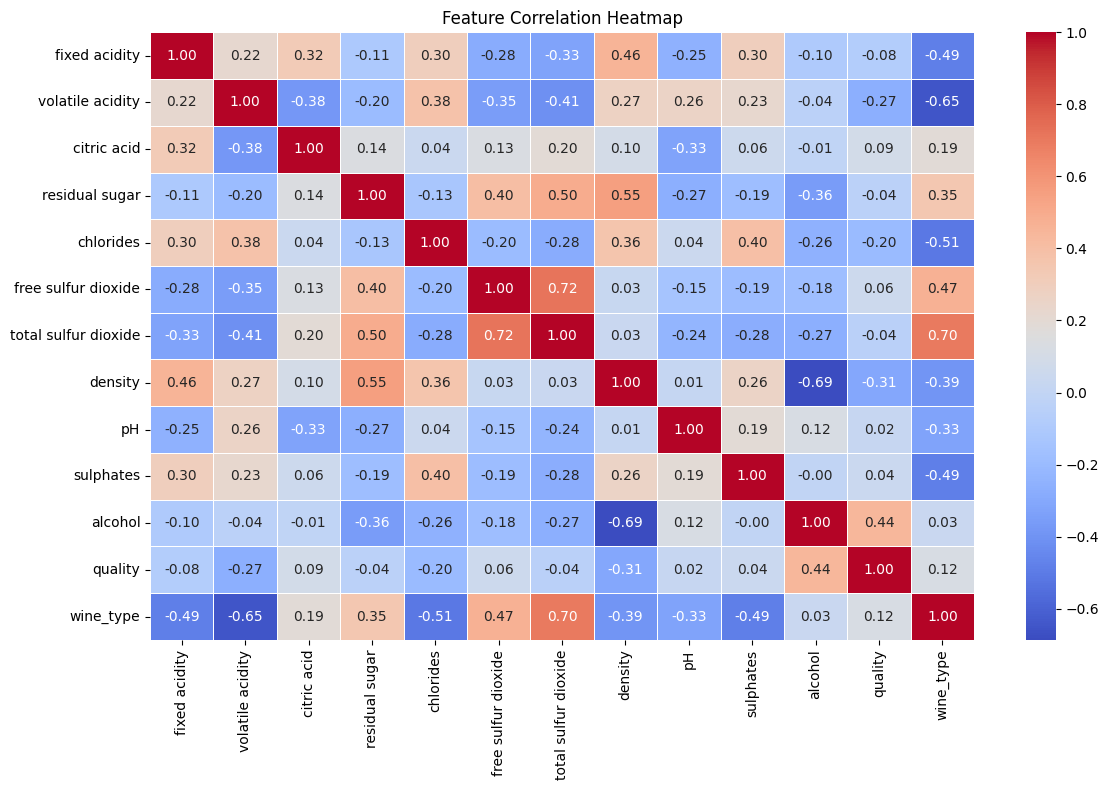

STEP 3: Split Dataset (80% Train / 20% Test)
Training samples : 5197
Testing  samples : 1300
✅ Split done!
STEP 4: Train Simple Linear Regression
✅ Model Trained!

Feature Coefficients:
             Feature  Coefficient
           sulphates       0.7630
                  pH       0.5276
             alcohol       0.2326
       fixed acidity       0.0921
      residual sugar       0.0628
 free sulfur dioxide       0.0060
total sulfur dioxide      -0.0016
         citric acid      -0.0979
           wine_type      -0.3352
           chlorides      -0.5826
    volatile acidity      -1.5088
             density    -102.0817


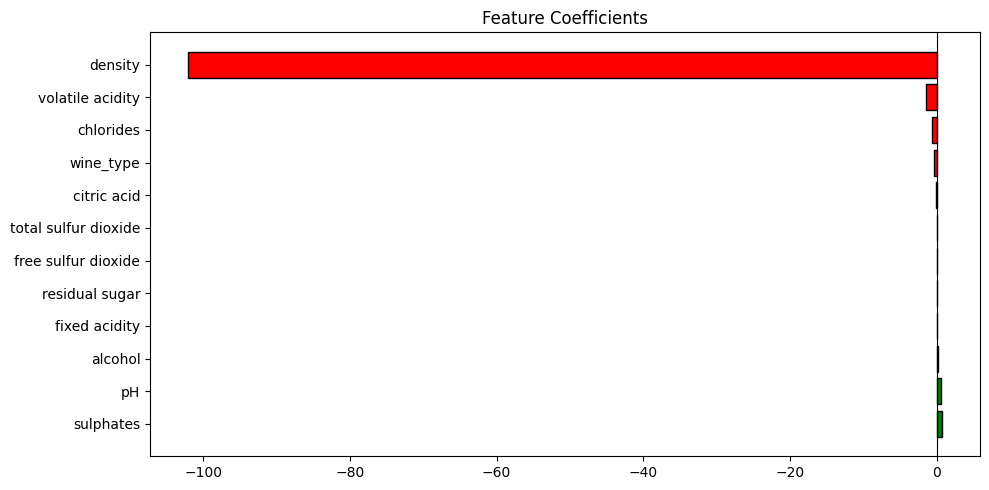

STEP 5: Training Dataset Results
MSE  (train) : 0.5356
RMSE (train) : 0.7318
R²   (train) : 0.3029


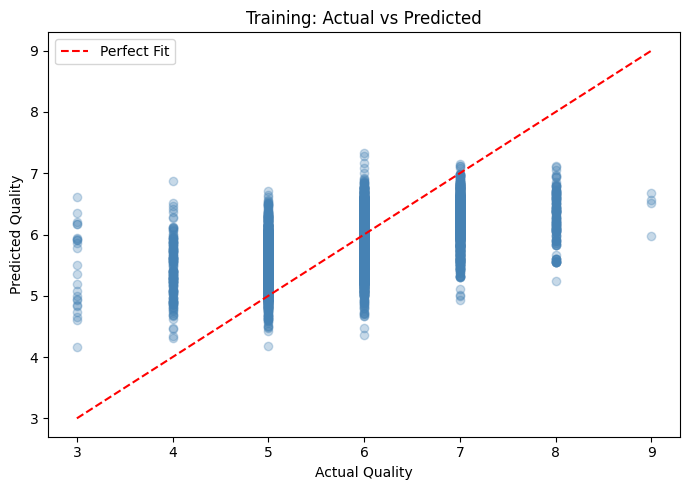

STEP 6: Regression Evaluation Matrix

→ Dataset Nature: REGRESSION (score 3–9)

  MSE  = 0.5356  (lower is better)
  RMSE = 0.7318  (off by ~0.73 quality points)
  R²   = 0.3029  (explains 30.3% of variance)
STEP 7: Classification Metrics
  Accuracy  : 0.5385  (53.8%)
  Precision : 0.5096  (51.0%)
  F1-Score  : 0.5044  (50.4%)

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.25      0.02      0.04        43
           5       0.56      0.53      0.54       402
           6       0.54      0.74      0.62       597
           7       0.50      0.22      0.30       215
           8       0.00      0.00      0.00        36
           9       0.00      0.00      0.00         1

    accuracy                           0.54      1300
   macro avg       0.26      0.22      0.22      1300
weighted avg       0.51      0.54      0.50      1300



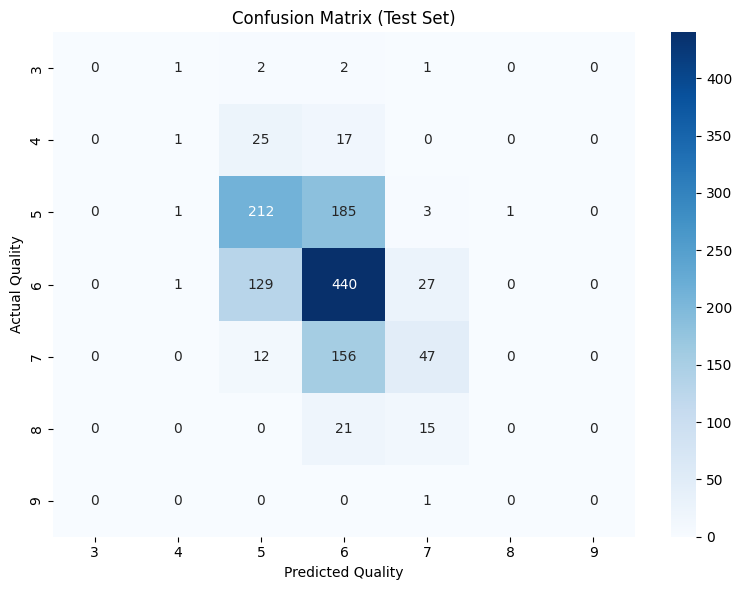

STEP 8: Testing Dataset Results
MSE  (test) : 0.5412
RMSE (test) : 0.7357
R²   (test) : 0.2672


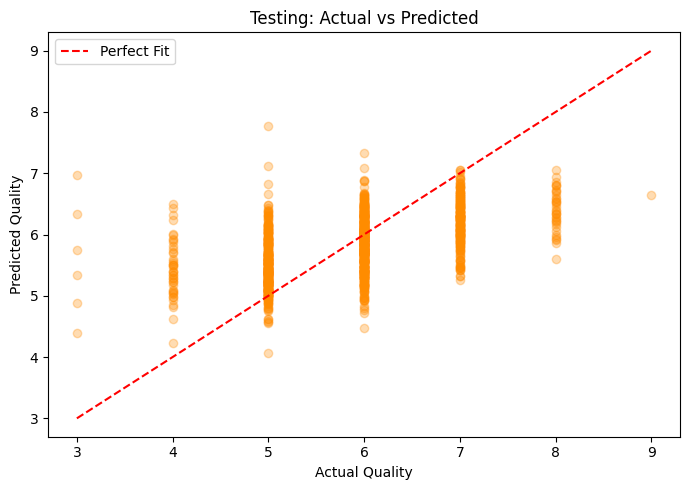

STEP 9: FINAL RESULTS TABLE
   Metric Training Testing
      MSE   0.5356  0.5412
     RMSE   0.7318  0.7357
 R² Score   0.3029  0.2672
 Accuracy        —  0.5385
Precision        —  0.5096
 F1-Score        —  0.5044

CONCLUSION
• R² = 0.2672 → model explains 26.7% of variance
• RMSE = 0.7357 → predictions off by ±0.74 quality points
• Accuracy = 53.8%
• No overfitting (train ≈ test) ✅
• Try Random Forest for better results 🚀

🎉 All 9 Steps Completed!


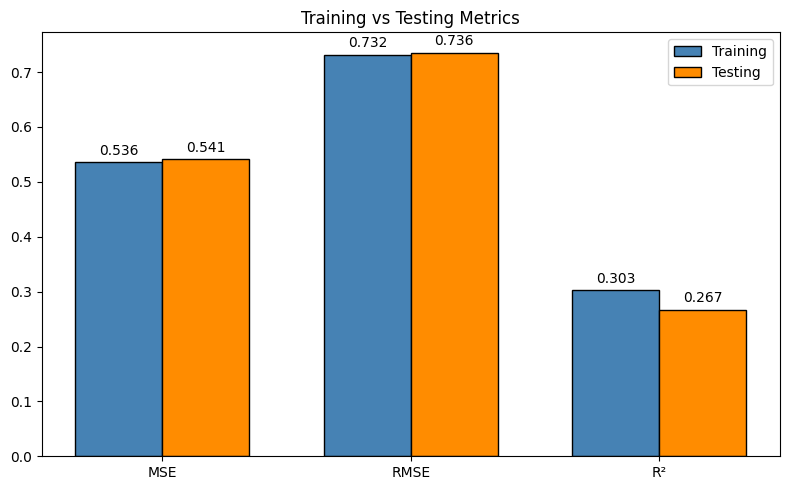

In [4]:
# ============================================================
# 🍷 WINE QUALITY - COMPLETE ML PIPELINE
# Copy each section into a NEW Colab cell
# ============================================================

# ── CELL 1: Import Libraries ─────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, precision_score,
                             f1_score, confusion_matrix,
                             classification_report)
print("✅ Libraries imported!")

# ── CELL 2: STEP 1 - Load Dataset ────────────────────────────
url_red   = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
url_white = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'

red   = pd.read_csv(url_red,   sep=';')
white = pd.read_csv(url_white, sep=';')
red['wine_type']   = 'red'
white['wine_type'] = 'white'
df = pd.concat([red, white], ignore_index=True)

print("=" * 50)
print("STEP 1: Dataset Loaded")
print("=" * 50)
print(f"Red wine rows   : {len(red)}")
print(f"White wine rows : {len(white)}")
print(f"Total rows      : {len(df)}")
print(f"Columns         : {df.shape[1]}")
df.head()

# ── CELL 3: STEP 2 - Pre-Processing ──────────────────────────
print("=" * 50)
print("STEP 2: Pre-Processing")
print("=" * 50)

print("\nMissing values:")
print(df.isnull().sum())
df.fillna(df.mean(numeric_only=True), inplace=True)
print("✅ Missing values handled")

df['wine_type'] = df['wine_type'].map({'red': 0, 'white': 1})
print("✅ wine_type encoded: red=0, white=1")

print("\nBasic Statistics:")
df.describe().round(2)

# ── CELL 4: Quality Distribution Plot ────────────────────────
plt.figure(figsize=(8, 4))
df['quality'].value_counts().sort_index().plot(
    kind='bar', color='steelblue', edgecolor='black')
plt.title('Wine Quality Score Distribution')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ── CELL 5: Correlation Heatmap ──────────────────────────────
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True,
            fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# ── CELL 6: STEP 3 - Split Dataset ───────────────────────────
print("=" * 50)
print("STEP 3: Split Dataset (80% Train / 20% Test)")
print("=" * 50)

X = df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")
print("✅ Split done!")

# ── CELL 7: STEP 4 - Train Model ─────────────────────────────
print("=" * 50)
print("STEP 4: Train Simple Linear Regression")
print("=" * 50)

model = LinearRegression()
model.fit(X_train, y_train)
print("✅ Model Trained!")

coeff_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': model.coef_.round(4)
}).sort_values('Coefficient', ascending=False)
print("\nFeature Coefficients:")
print(coeff_df.to_string(index=False))

# ── CELL 8: Coefficients Plot ─────────────────────────────────
plt.figure(figsize=(10, 5))
colors = ['green' if c > 0 else 'red' for c in coeff_df['Coefficient']]
plt.barh(coeff_df['Feature'], coeff_df['Coefficient'],
         color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Coefficients')
plt.tight_layout()
plt.show()

# ── CELL 9: STEP 5 - Training Results ────────────────────────
print("=" * 50)
print("STEP 5: Training Dataset Results")
print("=" * 50)

y_train_pred = model.predict(X_train)
mse_train    = mean_squared_error(y_train, y_train_pred)
rmse_train   = np.sqrt(mse_train)
r2_train     = r2_score(y_train, y_train_pred)

print(f"MSE  (train) : {mse_train:.4f}")
print(f"RMSE (train) : {rmse_train:.4f}")
print(f"R²   (train) : {r2_train:.4f}")

plt.figure(figsize=(7, 5))
plt.scatter(y_train, y_train_pred, alpha=0.3, color='steelblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect Fit')
plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')
plt.title('Training: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

# ── CELL 10: STEP 6 - Regression Metrics ─────────────────────
print("=" * 50)
print("STEP 6: Regression Evaluation Matrix")
print("=" * 50)
print(f"\n→ Dataset Nature: REGRESSION (score 3–9)")
print(f"\n  MSE  = {mse_train:.4f}  (lower is better)")
print(f"  RMSE = {rmse_train:.4f}  (off by ~{rmse_train:.2f} quality points)")
print(f"  R²   = {r2_train:.4f}  (explains {r2_train*100:.1f}% of variance)")

# ── CELL 11: STEP 7 - Classification Metrics ─────────────────
print("=" * 50)
print("STEP 7: Classification Metrics")
print("=" * 50)

y_test_pred  = model.predict(X_test)
y_pred_class = np.clip(
    np.round(y_test_pred).astype(int), int(y.min()), int(y.max()))

acc  = accuracy_score(y_test, y_pred_class)
prec = precision_score(y_test, y_pred_class, average='weighted', zero_division=0)
f1   = f1_score(y_test, y_pred_class, average='weighted', zero_division=0)

print(f"  Accuracy  : {acc:.4f}  ({acc*100:.1f}%)")
print(f"  Precision : {prec:.4f}  ({prec*100:.1f}%)")
print(f"  F1-Score  : {f1:.4f}  ({f1*100:.1f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_class, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y.unique()),
            yticklabels=sorted(y.unique()))
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.tight_layout()
plt.show()

# ── CELL 12: STEP 8 - Testing Results ────────────────────────
print("=" * 50)
print("STEP 8: Testing Dataset Results")
print("=" * 50)

mse_test  = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test   = r2_score(y_test, y_test_pred)

print(f"MSE  (test) : {mse_test:.4f}")
print(f"RMSE (test) : {rmse_test:.4f}")
print(f"R²   (test) : {r2_test:.4f}")

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_test_pred, alpha=0.3, color='darkorange')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect Fit')
plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')
plt.title('Testing: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

# ── CELL 13: STEP 9 - Final Table ────────────────────────────
print("=" * 55)
print("STEP 9: FINAL RESULTS TABLE")
print("=" * 55)

final_table = pd.DataFrame({
    'Metric'  : ['MSE', 'RMSE', 'R² Score', 'Accuracy', 'Precision', 'F1-Score'],
    'Training': [f'{mse_train:.4f}', f'{rmse_train:.4f}',
                 f'{r2_train:.4f}', '—', '—', '—'],
    'Testing' : [f'{mse_test:.4f}',  f'{rmse_test:.4f}',
                 f'{r2_test:.4f}',   f'{acc:.4f}', f'{prec:.4f}', f'{f1:.4f}']
})
print(final_table.to_string(index=False))

print("\nCONCLUSION")
print(f"• R² = {r2_test:.4f} → model explains {r2_test*100:.1f}% of variance")
print(f"• RMSE = {rmse_test:.4f} → predictions off by ±{rmse_test:.2f} quality points")
print(f"• Accuracy = {acc*100:.1f}%")
print(f"• No overfitting (train ≈ test) ✅")
print("• Try Random Forest for better results 🚀")
print("\n🎉 All 9 Steps Completed!")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
metrics = ['MSE', 'RMSE', 'R²']
train_v = [mse_train, rmse_train, r2_train]
test_v  = [mse_test,  rmse_test,  r2_test]
x = np.arange(len(metrics))
w = 0.35
b1 = ax.bar(x - w/2, train_v, w, label='Training', color='steelblue',   edgecolor='black')
b2 = ax.bar(x + w/2, test_v,  w, label='Testing',  color='darkorange', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_title('Training vs Testing Metrics')
ax.legend()
ax.bar_label(b1, fmt='%.3f', padding=3)
ax.bar_label(b2, fmt='%.3f', padding=3)
plt.tight_layout()
plt.show()
